In [1]:
from pathlib import Path
import sys
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

# Find project root
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Make src importable
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DATA_DIR,
    RAW_DIR,
    FC1_RAW_DIR,
    FC2_RAW_DIR,
    PROCESSED_DIR,
    FIX_DATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    EIS_COLUMNS,
    POLARIZATION_COLUMNS,
    AGEING_COLUMNS,
    AGEING_TIME_UNIT,
)

STAGE1_DIR = PROCESSED_DIR / "stage1"
STAGE1_FIGURE_DIR = FIGURE_DIR / "stage1"

STAGE1_DIR.mkdir(parents=True, exist_ok=True)
FIX_DATA_DIR.mkdir(parents=True, exist_ok=True)
STAGE1_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("FC1 raw dir:", FC1_RAW_DIR)
print("FC2 raw dir:", FC2_RAW_DIR)
print("Fix data dir:", FIX_DATA_DIR)

Project root: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics
Raw dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\raw
FC1 raw dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\raw\FC1_Without_Ripples_Excel
FC2 raw dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\raw\FC2_With_Ripples_Excel
Fix data dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\fix_data


In [2]:
folder_checks = {
    "RAW_DIR exists": RAW_DIR.exists(),
    "FC1_RAW_DIR exists": FC1_RAW_DIR.exists(),
    "FC2_RAW_DIR exists": FC2_RAW_DIR.exists(),
    "FIX_DATA_DIR exists": FIX_DATA_DIR.exists(),
    "STAGE1_DIR exists": STAGE1_DIR.exists(),
}

for name, status in folder_checks.items():
    print(f"{name}: {status}")

RAW_DIR exists: True
FC1_RAW_DIR exists: True
FC2_RAW_DIR exists: True
FIX_DATA_DIR exists: True
STAGE1_DIR exists: True


In [3]:
def natural_sort_key(path):
    path = str(path)
    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", path)
    ]


def scan_data_files(raw_dir):
    """
    Scan recursively for raw data files.
    """
    allowed_extensions = {".csv", ".xlsx", ".xls", ".txt", ".dat"}
    
    files = []
    
    for path in Path(raw_dir).rglob("*"):
        if path.is_file():
            if path.suffix.lower() in allowed_extensions:
                if not path.name.startswith("~$"):
                    files.append(path)
    
    files = sorted(files, key=natural_sort_key)
    return files


all_raw_files = scan_data_files(RAW_DIR)

print("Total raw data files:", len(all_raw_files))

print("\nFirst 30 raw files:")
for f in all_raw_files[:30]:
    print(f.relative_to(PROJECT_ROOT))

Total raw data files: 76

First 30 raw files:
data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_part1.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_part2.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_part3.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T000.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T048.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T185.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T348.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T515.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T658.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T823.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T991.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_postpola_T000.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_postpola_T048.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_postpola_T185.xlsx
data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_postpola_T348.xlsx
dat

In [4]:
def parse_filename(file_path):
    file_path = Path(file_path)
    name = file_path.stem
    
    info = {
        "file_name": file_path.name,
        "file_stem": file_path.stem,
        "file_path": str(file_path),
        "relative_path": str(file_path.relative_to(PROJECT_ROOT)),
        "folder": file_path.parent.name,
        "suffix": file_path.suffix.lower(),
        "stack": None,
        "data_kind": "unknown",
        "time_h": np.nan,
        "part": np.nan,
        "current_A": np.nan,
        "eis_stage": None,
    }
    
    # Detect stack from full path
    m_stack = re.search(r"(FC\d+)", str(file_path), re.IGNORECASE)
    if m_stack:
        info["stack"] = m_stack.group(1).upper()
    
    # Ageing file
    m = re.search(
        r"(?P<stack>FC\d+)_Ageing_part(?P<part>\d+)",
        name,
        re.IGNORECASE
    )
    if m:
        info["stack"] = m.group("stack").upper()
        info["data_kind"] = "ageing"
        info["part"] = int(m.group("part"))
        return info
    
    # Polarization file
    m = re.search(
        r"(?P<stack>FC\d+)_Pola_T(?P<time>\d+)",
        name,
        re.IGNORECASE
    )
    if m:
        info["stack"] = m.group("stack").upper()
        info["data_kind"] = "polarization"
        info["time_h"] = int(m.group("time"))
        return info
    
    # EIS file
    m = re.search(
        r"(?P<stack>FC\d+)_EIS(?P<current>\d+)A_(?P<stage>pre|post)pola_T(?P<time>\d+)",
        name,
        re.IGNORECASE
    )
    if m:
        info["stack"] = m.group("stack").upper()
        info["data_kind"] = "eis"
        info["current_A"] = int(m.group("current"))
        info["eis_stage"] = m.group("stage").lower() + "pola"
        info["time_h"] = int(m.group("time"))
        return info
    
    return info


def build_raw_registry(raw_dir):
    files = scan_data_files(raw_dir)
    records = [parse_filename(f) for f in files]
    
    registry = pd.DataFrame(records)
    
    registry = registry.sort_values(
        by=[
            "stack",
            "data_kind",
            "time_h",
            "current_A",
            "eis_stage",
            "part",
            "file_name",
        ],
        na_position="last"
    ).reset_index(drop=True)
    
    return registry


raw_registry = build_raw_registry(RAW_DIR)

print("Raw registry shape:", raw_registry.shape)
display(raw_registry.head(30))

Raw registry shape: (76, 12)


,file_name,file_stem,file_path,relative_path,folder,suffix,stack,data_kind,time_h,part,current_A,eis_stage
0,FC1_Ageing_part1.xlsx,FC1_Ageing_part1,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,.xlsx,FC1,ageing,NaN,1.0,NaN,None
1,FC1_Ageing_part2.xlsx,FC1_Ageing_part2,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,.xlsx,FC1,ageing,NaN,2.0,NaN,None
2,FC1_Ageing_part3.xlsx,FC1_Ageing_part3,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,.xlsx,FC1,ageing,NaN,3.0,NaN,None
3,FC1_EIS20A_postpola_T000.xlsx,FC1_EIS20A_postpola_T000,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,0.0,NaN,20.0,postpola
4,FC1_EIS45A_postpola_T000.xlsx,FC1_EIS45A_postpola_T000,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,0.0,NaN,45.0,postpola
5,FC1_EIS70A_postpola_T000.xlsx,FC1_EIS70A_postpola_T000,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,0.0,NaN,70.0,postpola
6,FC1_EIS20A_postpola_T048.xlsx,FC1_EIS20A_postpola_T048,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,48.0,NaN,20.0,postpola
7,FC1_EIS45A_postpola_T048.xlsx,FC1_EIS45A_postpola_T048,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,48.0,NaN,45.0,postpola
8,FC1_EIS70A_postpola_T048.xlsx,FC1_EIS70A_postpola_T048,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,48.0,NaN,70.0,postpola
9,FC1_EIS70A_prepola_T048.xlsx,FC1_EIS70A_prepola_T048,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,.xlsx,FC1,eis,48.0,NaN,70.0,prepola


In [5]:
print("Data kind counts:")
display(raw_registry["data_kind"].value_counts(dropna=False))

print("\nStack counts:")
display(raw_registry["stack"].value_counts(dropna=False))

print("\nCounts by stack and data type:")
display(pd.crosstab(raw_registry["stack"], raw_registry["data_kind"]))

unknown_files = raw_registry[raw_registry["data_kind"] == "unknown"]

print("\nUnknown files:", len(unknown_files))
display(unknown_files[["file_name", "relative_path", "stack", "data_kind"]])

Data kind counts:


data_kind
eis             55
polarization    16
ageing           5
Name: count, dtype: int64


Stack counts:


stack
FC1    42
FC2    34
Name: count, dtype: int64


Counts by stack and data type:


data_kind,ageing,eis,polarization
stack,,,
FC1,3,31,8
FC2,2,24,8



Unknown files: 0


,file_name,relative_path,stack,data_kind


In [6]:
raw_registry_path = STAGE1_DIR / "raw_file_registry.csv"
raw_registry.to_csv(raw_registry_path, index=False)

print("Saved raw registry:")
print(raw_registry_path)

Saved raw registry:
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\raw_file_registry.csv


Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage1\raw_file_counts_by_stack_and_type.png


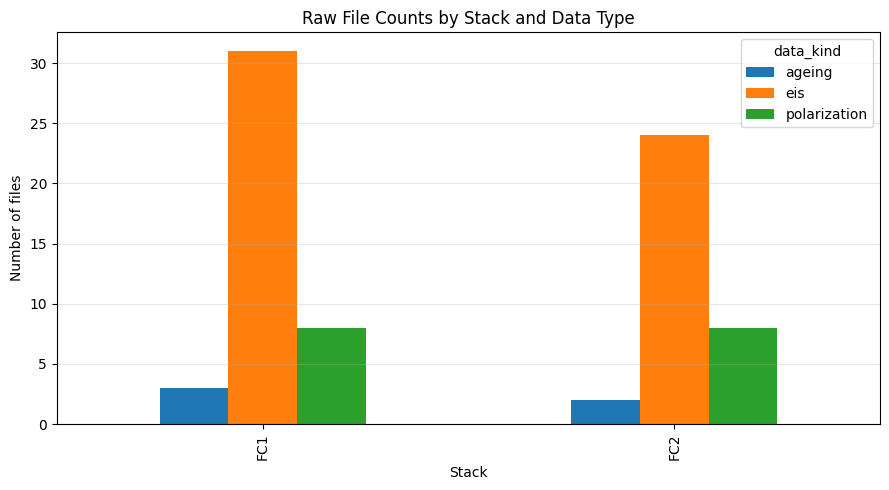

data_kind,ageing,eis,polarization
stack,,,
FC1,3,31,8
FC2,2,24,8


In [7]:
def plot_raw_file_counts(raw_registry):
    table = pd.crosstab(raw_registry["stack"], raw_registry["data_kind"])
    
    ax = table.plot(kind="bar", figsize=(9, 5))
    ax.set_xlabel("Stack")
    ax.set_ylabel("Number of files")
    ax.set_title("Raw File Counts by Stack and Data Type")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    out_path = STAGE1_FIGURE_DIR / "raw_file_counts_by_stack_and_type.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved:", out_path)
    
    plt.show()
    
    return table


raw_count_table = plot_raw_file_counts(raw_registry)
display(raw_count_table)

In [8]:
def parse_mixed_number(x):
    """
    Convert messy numeric strings into float.
    
    Handles:
    1.00E+04
    1,00E+04
    4.60E-03
    4,60E-03
    -8.67E-02
    -8,67E-02
    """
    if x is None:
        return np.nan
    
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip()
    
    if s == "":
        return np.nan
    
    s = s.replace(" ", "")
    s = s.replace("\u00a0", "")
    s = s.replace("−", "-")
    s = s.replace("\u2212", "-")
    
    if ";" in s:
        return np.nan
    
    # Decimal comma only
    if "," in s and "." not in s:
        s = s.replace(",", ".")
    
    # Both comma and dot
    elif "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            # 1.234,56
            s = s.replace(".", "").replace(",", ".")
        else:
            # 1,234.56
            s = s.replace(",", "")
    
    try:
        return float(s)
    except Exception:
        return np.nan

In [9]:
def read_raw_cells(file_path, sheet_name=0):
    """
    Read raw file without trusting delimiter/header.
    Excel is read as raw cells.
    CSV/TXT/DAT is read as raw lines.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    
    if suffix in [".xlsx", ".xls"]:
        raw = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=None,
            dtype=str
        )
        return raw
    
    elif suffix in [".csv", ".txt", ".dat"]:
        text = file_path.read_text(encoding="utf-8", errors="ignore")
        lines = text.splitlines()
        raw = pd.DataFrame({0: lines})
        return raw
    
    else:
        raise ValueError(f"Unsupported file type: {suffix}")

In [10]:
def is_probably_header_or_text(cells):
    """
    Detect header rows, not data rows.
    """
    text = " ".join([
        str(c).lower()
        for c in cells
        if c is not None and not pd.isna(c)
    ])
    
    header_keywords = [
        "frequency",
        "freq",
        "hz",
        "ohm",
        "rez",
        "imz",
        "time",
        "utot",
        "ustack",
        "u1",
        "u2",
        "u3",
        "u4",
        "u5",
        "current",
        "density",
        "temperature",
        "pressure",
        "flow",
        "humidity",
        "mbara",
        "l/mn",
        "a/cm",
        "tin",
        "tout",
        "pin",
        "pout",
        "din",
        "dout",
    ]
    
    return any(keyword in text for keyword in header_keywords)

In [11]:
def parse_numeric_row_from_cells(cells, expected_n_cols):
    """
    Parse one row into expected_n_cols numeric values.

    Works for:
    1. Normal Excel columns
    2. Semicolon-separated text in one cell
    3. Decimal-comma rows split across columns
    """
    
    clean_cells = []
    
    for c in cells:
        if c is None:
            continue
        if pd.isna(c):
            continue
        
        s = str(c).strip()
        
        if s == "":
            continue
        if s.lower().startswith("unnamed"):
            continue
        
        clean_cells.append(s)
    
    if len(clean_cells) == 0:
        return None, "empty"
    
    if is_probably_header_or_text(clean_cells):
        return None, "header"
    
    # Method 1: normal columns
    if len(clean_cells) >= expected_n_cols:
        vals = [
            parse_mixed_number(clean_cells[i])
            for i in range(expected_n_cols)
        ]
        
        if all(np.isfinite(v) for v in vals):
            return vals, "normal_columns"
    
    # Method 2: repair decimal-comma split
    reconstructed_line = ",".join(clean_cells)
    
    if ";" in reconstructed_line:
        fields = reconstructed_line.split(";")
        
        if len(fields) >= expected_n_cols:
            vals = [
                parse_mixed_number(fields[i])
                for i in range(expected_n_cols)
            ]
            
            if all(np.isfinite(v) for v in vals):
                return vals, "repaired_decimal_comma_split"
    
    # Method 3: semicolon row
    single_line = " ".join(clean_cells)
    
    if ";" in single_line:
        fields = single_line.split(";")
        
        if len(fields) >= expected_n_cols:
            vals = [
                parse_mixed_number(fields[i])
                for i in range(expected_n_cols)
            ]
            
            if all(np.isfinite(v) for v in vals):
                return vals, "repaired_semicolon_line"
    
    return None, "failed_to_parse"

In [12]:
def standardize_numeric_file_from_raw_cells(raw_df, expected_columns):
    """
    Convert raw cells into a clean numeric dataframe.
    """
    expected_n_cols = len(expected_columns)
    
    records = []
    modes = []
    
    failed_rows = 0
    header_rows = 0
    empty_rows = 0
    
    for _, row in raw_df.iterrows():
        cells = row.tolist()
        
        parsed, mode = parse_numeric_row_from_cells(
            cells,
            expected_n_cols=expected_n_cols
        )
        
        if parsed is not None:
            records.append(parsed)
            modes.append(mode)
        else:
            if mode == "header":
                header_rows += 1
            elif mode == "empty":
                empty_rows += 1
            else:
                failed_rows += 1
    
    clean_df = pd.DataFrame(records, columns=expected_columns)
    
    mode_counts = pd.Series(modes).value_counts().to_dict() if modes else {}
    
    if len(clean_df) == 0:
        repair_status = "failed"
    elif any("repaired" in mode for mode in mode_counts.keys()):
        repair_status = "repaired"
    else:
        repair_status = "normal"
    
    metadata = {
        "repair_status": repair_status,
        "mode_counts": mode_counts,
        "n_clean_rows": len(clean_df),
        "n_failed_rows": failed_rows,
        "n_header_rows": header_rows,
        "n_empty_rows": empty_rows,
    }
    
    return clean_df, metadata

In [13]:
def standardize_file_by_kind(file_path, data_kind):
    """
    Standardize EIS, polarization, or ageing file.
    """
    raw_df = read_raw_cells(file_path)
    
    if data_kind == "eis":
        clean_df, meta = standardize_numeric_file_from_raw_cells(
            raw_df,
            EIS_COLUMNS
        )
    
    elif data_kind == "polarization":
        clean_df, meta = standardize_numeric_file_from_raw_cells(
            raw_df,
            POLARIZATION_COLUMNS
        )
    
    elif data_kind == "ageing":
        clean_df, meta = standardize_numeric_file_from_raw_cells(
            raw_df,
            AGEING_COLUMNS
        )
        
        if len(clean_df) > 0:
            if AGEING_TIME_UNIT.lower() in ["s", "sec", "second", "seconds"]:
                clean_df["Time_h"] = clean_df["Time_raw"] / 3600.0
            else:
                clean_df["Time_h"] = clean_df["Time_raw"]
    
    else:
        raise ValueError(f"Unsupported data kind: {data_kind}")
    
    return clean_df, meta

In [15]:
def validate_fixed_eis(df):
    reasons = []
    
    if df is None or len(df) < 10:
        return False, f"too_few_rows_{0 if df is None else len(df)}"
    
    if (df["Frequency_Hz"] <= 0).mean() > 0.2:
        reasons.append("many_non_positive_frequencies")
    
    if df["Frequency_Hz"].nunique() < 5:
        reasons.append("frequency_not_varying")
    
    if df["ReZ_Ohm"].nunique() < 3:
        reasons.append("ReZ_not_varying")
    
    if df["ImZ_Ohm"].nunique() < 3:
        reasons.append("ImZ_not_varying")
    
    if reasons:
        return False, "; ".join(reasons)
    
    return True, "ok"


def validate_fixed_polarization(df):
    reasons = []
    
    if df is None or len(df) < 20:
        return False, f"too_few_rows_{0 if df is None else len(df)}"
    
    if df["Ustack_V"].nunique() < 5:
        reasons.append("Ustack_not_varying")
    
    if df["J_A_cm2"].nunique() < 5 and df["I_A"].nunique() < 5:
        reasons.append("current_not_varying")
    
    if reasons:
        return False, "; ".join(reasons)
    
    return True, "ok"


def validate_fixed_ageing(df):
    reasons = []
    
    if df is None or len(df) < 20:
        return False, f"too_few_rows_{0 if df is None else len(df)}"
    
    if df["Time_h"].nunique() < 5:
        reasons.append("time_not_varying")
    
    if df["Utot_V"].nunique() < 5:
        reasons.append("Utot_not_varying")
    
    if reasons:
        return False, "; ".join(reasons)
    
    return True, "ok"


def validate_fixed_file(df, data_kind):
    if data_kind == "eis":
        return validate_fixed_eis(df)
    
    if data_kind == "polarization":
        return validate_fixed_polarization(df)
    
    if data_kind == "ageing":
        return validate_fixed_ageing(df)
    
    return False, "unknown_data_kind"

In [16]:
def make_fixed_output_path(row):
    """
    Preserve FC1/FC2 folder structure inside fix_data.
    """
    folder = row["folder"]
    original_stem = Path(row["file_name"]).stem
    
    out_dir = FIX_DATA_DIR / folder
    out_dir.mkdir(parents=True, exist_ok=True)
    
    out_path = out_dir / f"{original_stem}_fixed.csv"
    return out_path


def fix_one_file(row):
    """
    Fix one file and save clean CSV if valid.
    """
    result = {
        "original_file": row["file_name"],
        "original_path": row["file_path"],
        "relative_path": row["relative_path"],
        "folder": row["folder"],
        "stack": row["stack"],
        "data_kind": row["data_kind"],
        "time_h": row["time_h"],
        "part": row["part"],
        "current_A": row["current_A"],
        "eis_stage": row["eis_stage"],
        "fix_success": False,
        "fixed_path": None,
        "repair_status": None,
        "repair_mode_counts": None,
        "n_clean_rows": 0,
        "n_failed_rows": 0,
        "n_header_rows": 0,
        "n_empty_rows": 0,
        "validation_reason": None,
    }
    
    try:
        if row["data_kind"] not in ["eis", "polarization", "ageing"]:
            result["validation_reason"] = "skipped_unknown_data_kind"
            return result
        
        clean_df, meta = standardize_file_by_kind(
            row["file_path"],
            row["data_kind"]
        )
        
        is_valid, validation_reason = validate_fixed_file(
            clean_df,
            row["data_kind"]
        )
        
        result["repair_status"] = meta["repair_status"]
        result["repair_mode_counts"] = str(meta["mode_counts"])
        result["n_clean_rows"] = meta["n_clean_rows"]
        result["n_failed_rows"] = meta["n_failed_rows"]
        result["n_header_rows"] = meta["n_header_rows"]
        result["n_empty_rows"] = meta["n_empty_rows"]
        result["validation_reason"] = validation_reason
        
        if is_valid:
            out_path = make_fixed_output_path(row)
            clean_df.to_csv(out_path, index=False)
            
            result["fix_success"] = True
            result["fixed_path"] = str(out_path)
        
        return result
    
    except Exception as e:
        result["validation_reason"] = f"fix_error: {e}"
        return result

In [17]:
fix_results = []

for idx, row in raw_registry.iterrows():
    res = fix_one_file(row)
    fix_results.append(res)

fix_registry = pd.DataFrame(fix_results)

print("Fix registry shape:", fix_registry.shape)
display(fix_registry.head(30))

Fix registry shape: (76, 19)


,original_file,original_path,relative_path,folder,stack,data_kind,time_h,part,current_A,eis_stage,fix_success,fixed_path,repair_status,repair_mode_counts,n_clean_rows,n_failed_rows,n_header_rows,n_empty_rows,validation_reason
0,FC1_Ageing_part1.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,1.0,NaN,None,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 65535},65535,0,1,0,ok
1,FC1_Ageing_part2.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,2.0,NaN,None,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 65535},65535,0,1,0,ok
2,FC1_Ageing_part3.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,3.0,NaN,None,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 12792},12792,0,1,0,ok
3,FC1_EIS20A_postpola_T000.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_...,FC1_Without_Ripples_Excel,FC1,eis,0.0,NaN,20.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
4,FC1_EIS45A_postpola_T000.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_...,FC1_Without_Ripples_Excel,FC1,eis,0.0,NaN,45.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
5,FC1_EIS70A_postpola_T000.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,FC1,eis,0.0,NaN,70.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
6,FC1_EIS20A_postpola_T048.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_...,FC1_Without_Ripples_Excel,FC1,eis,48.0,NaN,20.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
7,FC1_EIS45A_postpola_T048.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_...,FC1_Without_Ripples_Excel,FC1,eis,48.0,NaN,45.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
8,FC1_EIS70A_postpola_T048.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,FC1,eis,48.0,NaN,70.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
9,FC1_EIS70A_prepola_T048.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS70A_...,FC1_Without_Ripples_Excel,FC1,eis,48.0,NaN,70.0,prepola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok


In [19]:
success_registry = fix_registry[fix_registry["fix_success"] == True].copy()
failed_registry = fix_registry[fix_registry["fix_success"] == False].copy()

fix_registry_path = STAGE1_DIR / "fix_registry_all_files.csv"
success_registry_path = STAGE1_DIR / "fixed_file_registry.csv"
failed_registry_path = STAGE1_DIR / "failed_fix_registry.csv"

fix_registry.to_csv(fix_registry_path, index=False)
success_registry.to_csv(success_registry_path, index=False)
failed_registry.to_csv(failed_registry_path, index=False)

print("Total raw files:", len(raw_registry))
print("Successfully fixed/copied:", len(success_registry))
print("Failed/skipped:", len(failed_registry))

print("\nSaved:")
print(fix_registry_path)
print(success_registry_path)
print(failed_registry_path)

Total raw files: 76
Successfully fixed/copied: 76
Failed/skipped: 0

Saved:
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\fix_registry_all_files.csv
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\fixed_file_registry.csv
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\failed_fix_registry.csv


In [20]:
repaired_files = success_registry[
    success_registry["repair_status"] == "repaired"
].copy()

print("Repaired files:", len(repaired_files))

display(
    repaired_files[
        [
            "original_file",
            "stack",
            "data_kind",
            "time_h",
            "current_A",
            "eis_stage",
            "repair_status",
            "repair_mode_counts",
            "n_clean_rows",
            "n_failed_rows",
            "fixed_path",
        ]
    ].head(200)
)

Repaired files: 9


,original_file,stack,data_kind,time_h,current_A,eis_stage,repair_status,repair_mode_counts,n_clean_rows,n_failed_rows,fixed_path
43,FC2_Ageing_part2.csv,FC2,ageing,NaN,NaN,None,repaired,{'repaired_decimal_comma_split': 61835},61835,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
59,FC2_EIS20A_postpola_T666.csv,FC2,eis,666.0,20.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
60,FC2_EIS45A_postpola_T666.csv,FC2,eis,666.0,45.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
62,FC2_EIS20A_postpola_T830.csv,FC2,eis,830.0,20.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
63,FC2_EIS45A_postpola_T830.csv,FC2,eis,830.0,45.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
64,FC2_EIS70A_postpola_T830.csv,FC2,eis,830.0,70.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
65,FC2_EIS20A_postpola_T1016.csv,FC2,eis,1016.0,20.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
66,FC2_EIS45A_postpola_T1016.csv,FC2,eis,1016.0,45.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...
67,FC2_EIS70A_postpola_T1016.csv,FC2,eis,1016.0,70.0,postpola,repaired,{'repaired_decimal_comma_split': 78},78,0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...


In [21]:
print("Failed/skipped files:", len(failed_registry))

display(
    failed_registry[
        [
            "original_file",
            "stack",
            "data_kind",
            "time_h",
            "current_A",
            "eis_stage",
            "repair_status",
            "n_clean_rows",
            "n_failed_rows",
            "validation_reason",
            "relative_path",
        ]
    ].head(200)
)

Failed/skipped files: 0


,original_file,stack,data_kind,time_h,current_A,eis_stage,repair_status,n_clean_rows,n_failed_rows,validation_reason,relative_path


Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage1\fix_success_by_data_type.png


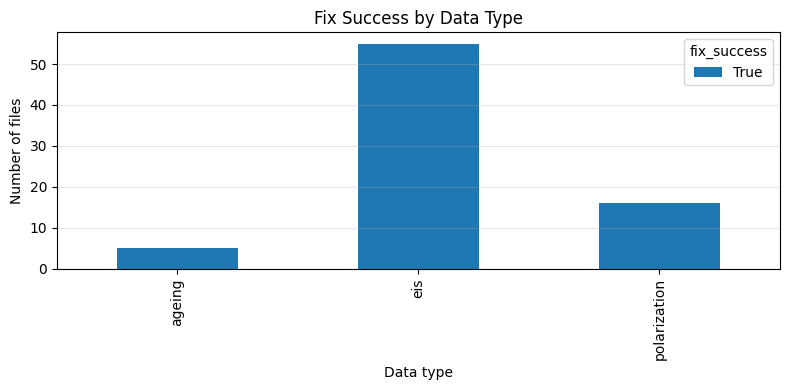

fix_success,True
data_kind,
ageing,5
eis,55
polarization,16


In [22]:
def plot_fix_success_counts(fix_registry):
    table = pd.crosstab(
        fix_registry["data_kind"],
        fix_registry["fix_success"]
    )
    
    ax = table.plot(kind="bar", figsize=(8, 4))
    ax.set_xlabel("Data type")
    ax.set_ylabel("Number of files")
    ax.set_title("Fix Success by Data Type")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    out_path = STAGE1_FIGURE_DIR / "fix_success_by_data_type.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved:", out_path)
    
    plt.show()
    
    return table


fix_success_table = plot_fix_success_counts(fix_registry)
display(fix_success_table)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage1\repair_status_by_data_type.png


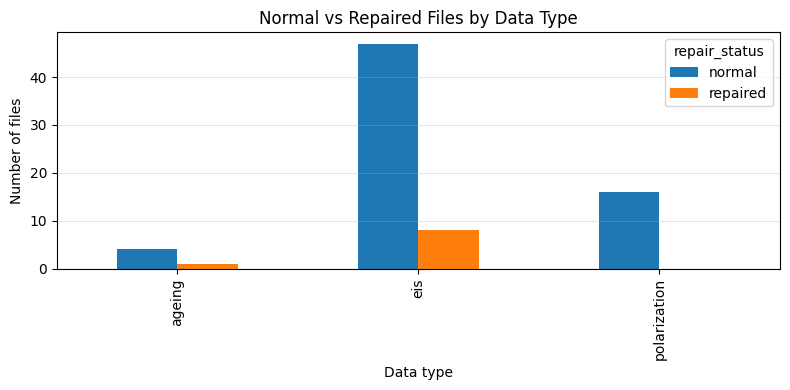

repair_status,normal,repaired
data_kind,,
ageing,4,1
eis,47,8
polarization,16,0


In [23]:
def plot_repair_status_counts(success_registry):
    table = pd.crosstab(
        success_registry["data_kind"],
        success_registry["repair_status"]
    )
    
    ax = table.plot(kind="bar", figsize=(8, 4))
    ax.set_xlabel("Data type")
    ax.set_ylabel("Number of files")
    ax.set_title("Normal vs Repaired Files by Data Type")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    out_path = STAGE1_FIGURE_DIR / "repair_status_by_data_type.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved:", out_path)
    
    plt.show()
    
    return table


repair_status_table = plot_repair_status_counts(success_registry)
display(repair_status_table)

In [24]:
fixed_eis = success_registry[success_registry["data_kind"] == "eis"].copy()

if len(fixed_eis) > 0:
    eis_availability = fixed_eis.pivot_table(
        index=["stack", "time_h"],
        columns=["current_A", "eis_stage"],
        values="fix_success",
        aggfunc="count",
        fill_value=0,
    )
    
    display(eis_availability)
    
    eis_availability_path = STAGE1_DIR / "fixed_eis_availability.csv"
    eis_availability.to_csv(eis_availability_path)
    
    print("Saved:", eis_availability_path)
else:
    print("No fixed EIS files.")

current_A        20.0     45.0     70.0        
eis_stage    postpola postpola postpola prepola
stack time_h                                   
FC1   0.0           1        1        1       0
      48.0          1        1        1       1
      185.0         1        1        1       1
      348.0         1        1        1       1
      515.0         1        1        1       1
      658.0         1        1        1       1
      823.0         1        1        1       1
      991.0         1        1        1       1
FC2   0.0           1        1        1       0
      35.0          1        1        1       0
      182.0         1        1        1       0
      343.0         1        1        1       0
      515.0         1        1        1       0
      666.0         1        1        1       0
      830.0         1        1        1       0
      1016.0        1        1        1       0

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\fixed_eis_availability.csv


In [25]:
fixed_pola = success_registry[success_registry["data_kind"] == "polarization"].copy()

if len(fixed_pola) > 0:
    pola_availability = fixed_pola.pivot_table(
        index=["stack", "time_h"],
        values="fix_success",
        aggfunc="count",
        fill_value=0,
    )
    
    display(pola_availability)
    
    pola_availability_path = STAGE1_DIR / "fixed_polarization_availability.csv"
    pola_availability.to_csv(pola_availability_path)
    
    print("Saved:", pola_availability_path)
else:
    print("No fixed polarization files.")

fix_success
stack time_h             
FC1   0.0               1
      48.0              1
      185.0             1
      348.0             1
      515.0             1
      658.0             1
      823.0             1
      991.0             1
FC2   0.0               1
      35.0              1
      182.0             1
      343.0             1
      515.0             1
      666.0             1
      830.0             1
      1016.0            1

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\fixed_polarization_availability.csv


In [26]:
fixed_csv_files = sorted(FIX_DATA_DIR.rglob("*_fixed.csv"), key=natural_sort_key)

print("Total fixed CSV files:", len(fixed_csv_files))

print("\nFirst 40 fixed files:")
for f in fixed_csv_files[:40]:
    print(f.relative_to(PROJECT_ROOT))

Total fixed CSV files: 76

First 40 fixed files:
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_Ageing_part1_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_Ageing_part2_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_Ageing_part3_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T000_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T048_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T185_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T348_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T515_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T658_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T823_fixed.csv
data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T991_fixed.csv
data\processed\fix_data\FC1_Without_Ripp

In [27]:
def preview_fixed_file(data_kind):
    sub = success_registry[success_registry["data_kind"] == data_kind]
    
    if sub.empty:
        print(f"No fixed {data_kind} files.")
        return None
    
    row = sub.iloc[0]
    df = pd.read_csv(row["fixed_path"])
    
    print("=" * 80)
    print("Data kind:", data_kind)
    print("Original:", row["original_file"])
    print("Fixed:", row["fixed_path"])
    print("Shape:", df.shape)
    display(df.head())
    
    return df


fixed_eis_preview = preview_fixed_file("eis")
fixed_pola_preview = preview_fixed_file("polarization")
fixed_ageing_preview = preview_fixed_file("ageing")

Data kind: eis
Original: FC1_EIS20A_postpola_T000.xlsx
Fixed: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_EIS20A_postpola_T000_fixed.csv
Shape: (78, 3)


,Frequency_Hz,ReZ_Ohm,ImZ_Ohm
0,10000.0,0.004837,-0.005273
1,8915.3,0.004845,-0.004692
2,7948.3,0.004839,-0.004156
3,7086.2,0.004842,-0.003678
4,6317.6,0.004840,-0.003244


Data kind: polarization
Original: FC1_Pola_T000.xlsx
Fixed: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_Pola_T000_fixed.csv
Shape: (5023, 8)


,U1_V,U2_V,U3_V,U4_V,U5_V,Ustack_V,I_A,J_A_cm2
0,0.619,0.61,0.611,0.606,0.602,3.048,100.254,1.00254
1,0.619,0.61,0.611,0.606,0.602,3.048,100.205,1.00205
2,0.620,0.61,0.611,0.606,0.603,3.050,100.161,1.00161
3,0.619,0.61,0.611,0.606,0.602,3.048,100.151,1.00151
4,0.619,0.61,0.611,0.606,0.602,3.048,100.156,1.00156


Data kind: ageing
Original: FC1_Ageing_part1.xlsx
Fixed: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\fix_data\FC1_Without_Ripples_Excel\FC1_Ageing_part1_fixed.csv
Shape: (65535, 26)


,Time_raw,U1_V,U2_V,U3_V,U4_V,U5_V,Utot_V,J_A_cm2,I_A,TinH2_C,ToutH2_C,TinAIR_C,ToutAIR_C,TinWAT_C,ToutWAT_C,PinAIR_mbara,PoutAIR_mbara,PoutH2_mbara,PinH2_mbara,DinH2_l_min,DoutH2_l_min,DinAIR_l_min,DoutAIR_l_min,DWAT_l_min,HrAIRFC_percent,Time_h
0,0.000000,0.670,0.663,0.664,0.662,0.658,3.317,0.70164,70.164,25.930,38.889,41.918,51.503,53.806,55.502,1302.204,1269.602,1305.319,1292.489,4.799,2.115,23.038,21.331,2.020,48.904,0.000000
1,0.000156,0.670,0.663,0.663,0.662,0.659,3.317,0.70164,70.164,25.945,38.912,41.914,51.491,53.823,55.502,1301.863,1269.829,1305.205,1292.432,4.799,2.115,23.036,21.331,2.019,48.901,0.000156
2,0.000321,0.670,0.663,0.663,0.662,0.658,3.316,0.70168,70.168,25.943,38.895,41.912,51.512,53.803,55.496,1302.261,1269.773,1305.547,1293.059,4.801,2.115,23.038,21.331,2.016,48.913,0.000321
3,0.000475,0.669,0.663,0.663,0.662,0.659,3.316,0.70164,70.164,25.945,38.907,41.912,51.503,53.815,55.505,1301.863,1269.886,1305.775,1292.945,4.797,2.114,23.036,21.350,2.016,48.894,0.000475
4,0.000624,0.669,0.663,0.663,0.662,0.659,3.316,0.70159,70.159,25.939,38.915,41.909,51.515,53.814,55.484,1302.034,1269.659,1305.661,1293.002,4.797,2.116,23.036,21.331,2.017,48.939,0.000624


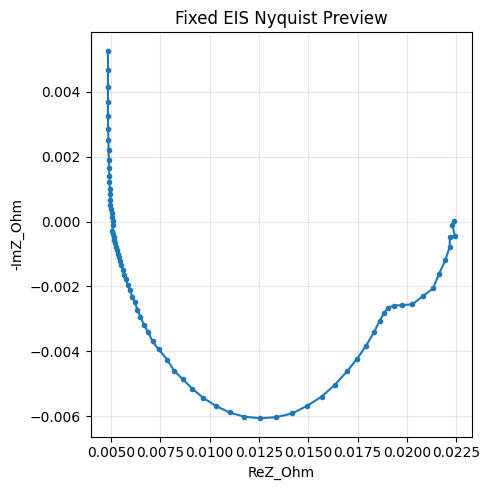

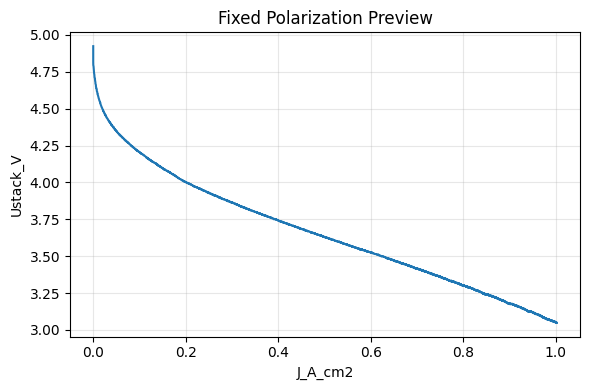

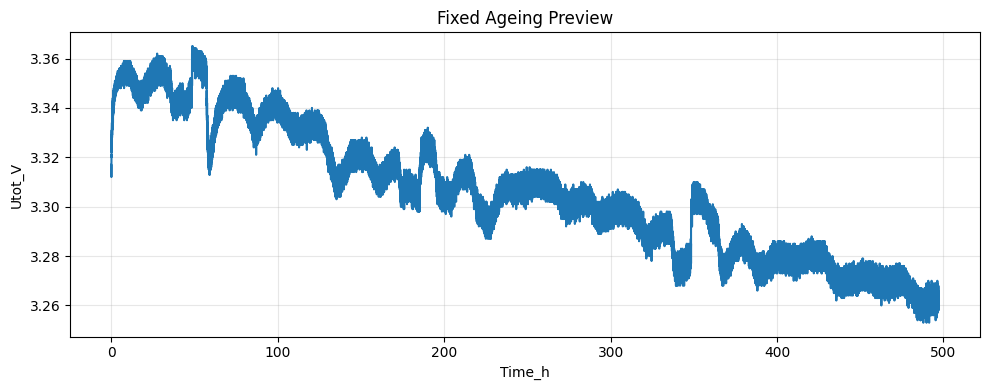

In [28]:
def quick_plot_fixed_eis(df):
    if df is None or df.empty:
        return
    
    plt.figure(figsize=(5, 5))
    plt.plot(df["ReZ_Ohm"], -df["ImZ_Ohm"], marker="o", markersize=3)
    plt.xlabel("ReZ_Ohm")
    plt.ylabel("-ImZ_Ohm")
    plt.title("Fixed EIS Nyquist Preview")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def quick_plot_fixed_polarization(df):
    if df is None or df.empty:
        return
    
    plt.figure(figsize=(6, 4))
    plt.plot(df["J_A_cm2"], df["Ustack_V"])
    plt.xlabel("J_A_cm2")
    plt.ylabel("Ustack_V")
    plt.title("Fixed Polarization Preview")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def quick_plot_fixed_ageing(df):
    if df is None or df.empty:
        return
    
    plt.figure(figsize=(10, 4))
    plt.plot(df["Time_h"], df["Utot_V"])
    plt.xlabel("Time_h")
    plt.ylabel("Utot_V")
    plt.title("Fixed Ageing Preview")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


quick_plot_fixed_eis(fixed_eis_preview)
quick_plot_fixed_polarization(fixed_pola_preview)
quick_plot_fixed_ageing(fixed_ageing_preview)

In [29]:
print("STAGE 1 FINAL SUMMARY")
print("=" * 80)

summary = {
    "raw_files_total": len(raw_registry),
    "fixed_files_success": len(success_registry),
    "fixed_files_failed_or_skipped": len(failed_registry),
    "fixed_eis_files": len(success_registry[success_registry["data_kind"] == "eis"]),
    "fixed_polarization_files": len(success_registry[success_registry["data_kind"] == "polarization"]),
    "fixed_ageing_files": len(success_registry[success_registry["data_kind"] == "ageing"]),
    "repaired_files": len(repaired_files),
    "fix_data_dir": str(FIX_DATA_DIR),
    "raw_registry_path": str(raw_registry_path),
    "success_registry_path": str(success_registry_path),
    "failed_registry_path": str(failed_registry_path),
}

for k, v in summary.items():
    print(f"{k}: {v}")

summary_path = STAGE1_DIR / "stage1_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print("\nSaved summary:")
print(summary_path)

print("\nStage 1 complete if:")
print("- fixed_files_success > 0")
print("- fixed_ageing_files > 0")
print("- fixed_polarization_files > 0")
print("- fixed_eis_files > 0")
print("- quick plots look reasonable")

STAGE 1 FINAL SUMMARY
raw_files_total: 76
fixed_files_success: 76
fixed_files_failed_or_skipped: 0
fixed_eis_files: 55
fixed_polarization_files: 16
fixed_ageing_files: 5
repaired_files: 9
fix_data_dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\fix_data
raw_registry_path: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\raw_file_registry.csv
success_registry_path: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\fixed_file_registry.csv
failed_registry_path: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\failed_fix_registry.csv

Saved summary:
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1\stage1_summary.json

Stage 1 complete if:
- fixed_files_success > 0
- fixed_ageing_files > 0
- fixed_polarization_files > 0
- fixed_eis_files > 0
- quick plots look reasonable
